In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy import stats
import joblib
import pickle
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

This project utilizes the Egyptian Real Estate Listings dataset, sourced from Property Finder Egypt, one of Egypt's largest real estate platforms. This authentic dataset contains 19,924 real estate listings covering various property types (apartments, villas, chalets, penthouses) from multiple Egyptian cities including Cairo, Alexandria, Giza, North Coast, Hurghada, and Sharm El-Sheikh. The dataset is characterized by its rich diversity, featuring both residential and commercial properties with prices ranging from a few million to hundreds of millions of Egyptian Pounds.



this database form kaggle.com and here the link "https://www.kaggle.com/datasets/hassankhaled21/egyptian-real-estate-listings/data"

In [3]:
df = pd.read_csv('egypt_real_estate_listings.csv')

In [4]:
df.shape

(19924, 11)

this data have 19924 row and 11 columns and our target value will be the price

In [5]:
df.head(10)

,url,price,description,location,type,size,bedrooms,bathrooms,available_from,payment_method,down_payment
0,https://www.propertyfinder.eg/en/plp/buy/chale...,"8,000,000",OWN A CHALET IN EL GOUNA WITH A PRIME LOCATION...,"Swan Lake Gouna, Al Gouna, Hurghada, Red Sea",Chalet,732 sqft / 68 sqm,1+ Maid,1,31 Aug 2025,Cash,"1,200,000 EGP"
1,https://www.propertyfinder.eg/en/plp/buy/villa...,"25,000,000","For sale, a villa with immediate delivery in C...","Karmell, New Zayed City, Sheikh Zayed City, Giza",Villa,"2,368 sqft / 220 sqm",4,4,2 Sep 2025,Cash,"2,100,000 EGP"
2,https://www.propertyfinder.eg/en/plp/buy/chale...,"15,135,000","With a down payment of EGP 1,513,000, a fully ...","Azha North, Ras Al Hekma, North Coast",Chalet,"1,270 sqft / 118 sqm",2,2,19 Aug 2025,Cash,"1,513,000 EGP"
3,https://www.propertyfinder.eg/en/plp/buy/apart...,"12,652,000",Own an apartment in New Cairo with a minimal d...,"Taj City, 5th Settlement Compounds, The 5th Se...",Apartment,"1,787 sqft / 166 sqm",3,2,26 Aug 2025,Installments,"1,260,000 EGP"
4,https://www.propertyfinder.eg/en/plp/buy/villa...,"45,250,000",Project: Granville\nLocation: Fifth Settlement...,"Granville, New Capital City, Cairo",Villa,"4,306 sqft / 400 sqm",7,7,2 Sep 2025,Cash,"2,262,500 EGP"
5,https://www.propertyfinder.eg/en/plp/buy/chale...,"19,760,000",Chalet with Marina and Lake View in The Island...,"Marina 5, Marina, Al Alamein, North Coast",Chalet,"1,356 sqft / 126 sqm",3,2,26 Aug 2025,Installments,"988,000 EGP"
6,https://www.propertyfinder.eg/en/plp/buy/penth...,"9,000,000",Penthouse 4BR for sale with Installments over ...,"The Icon Residence, 5th Settlement Compounds, ...",Penthouse,"2,820 sqft / 262 sqm",4,5,3 Jul 2025,Installments,NaN
7,https://www.propertyfinder.eg/en/plp/buy/villa...,"2,770,000","Stand-alone villa in NYOUM Compound, October\n...","Nyoum October, Northern Expansions, 6 October ...",Villa,"3,983 sqft / 370 sqm",5+ Maid,5,26 Aug 2025,Cash,NaN
8,https://www.propertyfinder.eg/en/plp/buy/twin-...,"13,200,000",**La Vista Ras El Hikma seaview twinhouse - Re...,"La vista Ras El Hikma, Ras Al Hekma, North Coast",Twin House,"2,368 sqft / 220 sqm",3,3,25 Aug 2025,Cash,NaN
9,https://www.propertyfinder.eg/en/plp/buy/duple...,"22,300,000",A 195-square-meter duplex + a 42-square-meter ...,"Azad, 5th Settlement Compounds, The 5th Settle...",Duplex,"2,099 sqft / 195 sqm",3+ Maid,2,7 Aug 2025,Installments,"2,230,000 EGP"


In [6]:
df.info(10)

<class 'pandas.DataFrame'>
RangeIndex: 19924 entries, 0 to 19923
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   url             19924 non-null  str  
 1   price           19385 non-null  str  
 2   description     19846 non-null  str  
 3   location        19833 non-null  str  
 4   type            19847 non-null  str  
 5   size            19847 non-null  str  
 6   bedrooms        19780 non-null  str  
 7   bathrooms       19784 non-null  str  
 8   available_from  19261 non-null  str  
 9   payment_method  19383 non-null  str  
 10  down_payment    5445 non-null   str  
dtypes: str(11)
memory usage: 24.5 MB


we will need to turn str to int 

In [7]:
df.describe()

,url,price,description,location,type,size,bedrooms,bathrooms,available_from,payment_method,down_payment
count,19924,19385,19846,19833,19847,19847,19780,19784,19261,19383,5445
unique,19924,4286,18130,1535,17,683,18,16,353,2,2030
top,https://www.propertyfinder.eg/en/plp/buy/chale...,"10,000,000",Please Note Before Reading:\nThis is one of ma...,"Marassi, Sidi Abdel Rahman, North Coast",Apartment,"1,507 sqft / 140 sqm",3,3,1 Sep 2025,Cash,"100,000 EGP"
freq,1,307,72,433,8355,432,4959,6562,3254,15521,203


In [8]:
df = df.drop(['url', 'description' , 'available_from'], axis=1)

We removed the url,description and available_from columns because they contain unstructured text data that doesn't provide quantifiable features for our regression model

In [9]:
df.head(10)

,price,location,type,size,bedrooms,bathrooms,payment_method,down_payment
0,"8,000,000","Swan Lake Gouna, Al Gouna, Hurghada, Red Sea",Chalet,732 sqft / 68 sqm,1+ Maid,1,Cash,"1,200,000 EGP"
1,"25,000,000","Karmell, New Zayed City, Sheikh Zayed City, Giza",Villa,"2,368 sqft / 220 sqm",4,4,Cash,"2,100,000 EGP"
2,"15,135,000","Azha North, Ras Al Hekma, North Coast",Chalet,"1,270 sqft / 118 sqm",2,2,Cash,"1,513,000 EGP"
3,"12,652,000","Taj City, 5th Settlement Compounds, The 5th Se...",Apartment,"1,787 sqft / 166 sqm",3,2,Installments,"1,260,000 EGP"
4,"45,250,000","Granville, New Capital City, Cairo",Villa,"4,306 sqft / 400 sqm",7,7,Cash,"2,262,500 EGP"
5,"19,760,000","Marina 5, Marina, Al Alamein, North Coast",Chalet,"1,356 sqft / 126 sqm",3,2,Installments,"988,000 EGP"
6,"9,000,000","The Icon Residence, 5th Settlement Compounds, ...",Penthouse,"2,820 sqft / 262 sqm",4,5,Installments,NaN
7,"2,770,000","Nyoum October, Northern Expansions, 6 October ...",Villa,"3,983 sqft / 370 sqm",5+ Maid,5,Cash,NaN
8,"13,200,000","La vista Ras El Hikma, Ras Al Hekma, North Coast",Twin House,"2,368 sqft / 220 sqm",3,3,Cash,NaN
9,"22,300,000","Azad, 5th Settlement Compounds, The 5th Settle...",Duplex,"2,099 sqft / 195 sqm",3+ Maid,2,Installments,"2,230,000 EGP"


In [10]:
df.duplicated().sum()

np.int64(830)

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.isnull().sum()

price               445
location             14
type                  1
size                  1
bedrooms             43
bathrooms            39
payment_method      447
down_payment      13791
dtype: int64

down_payment have a lot of null values so we will drop it too

In [14]:
df = df.drop(['down_payment'], axis=1)

In [15]:
df.head(10)

,price,location,type,size,bedrooms,bathrooms,payment_method
0,"8,000,000","Swan Lake Gouna, Al Gouna, Hurghada, Red Sea",Chalet,732 sqft / 68 sqm,1+ Maid,1,Cash
1,"25,000,000","Karmell, New Zayed City, Sheikh Zayed City, Giza",Villa,"2,368 sqft / 220 sqm",4,4,Cash
2,"15,135,000","Azha North, Ras Al Hekma, North Coast",Chalet,"1,270 sqft / 118 sqm",2,2,Cash
3,"12,652,000","Taj City, 5th Settlement Compounds, The 5th Se...",Apartment,"1,787 sqft / 166 sqm",3,2,Installments
4,"45,250,000","Granville, New Capital City, Cairo",Villa,"4,306 sqft / 400 sqm",7,7,Cash
5,"19,760,000","Marina 5, Marina, Al Alamein, North Coast",Chalet,"1,356 sqft / 126 sqm",3,2,Installments
6,"9,000,000","The Icon Residence, 5th Settlement Compounds, ...",Penthouse,"2,820 sqft / 262 sqm",4,5,Installments
7,"2,770,000","Nyoum October, Northern Expansions, 6 October ...",Villa,"3,983 sqft / 370 sqm",5+ Maid,5,Cash
8,"13,200,000","La vista Ras El Hikma, Ras Al Hekma, North Coast",Twin House,"2,368 sqft / 220 sqm",3,3,Cash
9,"22,300,000","Azad, 5th Settlement Compounds, The 5th Settle...",Duplex,"2,099 sqft / 195 sqm",3+ Maid,2,Installments


Numerical features is price , size , bedrooms and bathrooms
. Categorical features is location, type and payment_method

now we will start turn str to numeric

In [16]:
df['price'] = df['price'].str.replace(',', '', regex=False)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

In [17]:
def extract_sqm(size):

    if pd.isna(size) or str(size).strip() == '':
        return np.nan
    
    size_str = str(size).strip()

    sqm_match = re.search(r'(\d+(?:\.\d+)?)\s*sqm', size_str, re.IGNORECASE)
    
    if sqm_match:
        return float(sqm_match.group(1)) 

    return np.nan

df['size_sqm'] = df['size'].apply(extract_sqm)
df = df.drop('size', axis=1)


A maid's room is approximately half the size of a standard bedroom, so we will assign it 0.5 to accurately reflect its smaller contribution to property value while preserving it as a meaningful feature and Entries with "+" or "++" indicate unknown/incomplete data where the exact bedroom count cannot be verified. We marked these as 10 (above realistic range) and will remove them to prevent noise and maintain data quality in our regression model.

In [18]:
def clean_bedrooms(bed):
    if pd.isna(bed):
        return np.nan
    
    bed_str = str(bed).strip()
    
    if 'studio' in bed_str.lower():
        base = 0
        if 'maid' in bed_str.lower():
            return base + 0.5
        return base
    
    if '++' in bed_str:
        return 10.5 if 'maid' in bed_str.lower() else 10
    
    num_match = re.search(r'^(\d+)\+?$', bed_str)
    
    if num_match and '+' in bed_str and 'maid' not in bed_str.lower():
        return 10
    
    num_match2 = re.search(r'\d+', bed_str)
    
    if num_match2:
        base_num = float(num_match2.group())
        if 'maid' in bed_str.lower():
            return base_num + 0.5
        return base_num
    
    return np.nan

df['bedrooms'] = df['bedrooms'].apply(clean_bedrooms)

In [19]:
outlier_indices = df[df['bedrooms'] >= 10].index
df = df.drop(outlier_indices)

we will do the same thing with bathroom if we find + we will turn it to 10 then delete it

In [20]:
def clean_bathrooms(bath):
    if pd.isna(bath):
        return np.nan
    
    bath_str = str(bath).strip().lower()
    
    if bath_str == 'none':
        return 0
    
    if '+' in bath_str:
        return 10
    
    try:
        return float(bath_str)
    except:
        return np.nan

df['bathrooms'] = df['bathrooms'].apply(clean_bathrooms) 

In [21]:
outlier_indices = df[df['bathrooms'] == 10].index
df = df.drop(outlier_indices)

In [22]:
df.info()

<class 'pandas.DataFrame'>
Index: 18918 entries, 0 to 19923
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   price           18489 non-null  float64
 1   location        18905 non-null  str    
 2   type            18917 non-null  str    
 3   bedrooms        18875 non-null  float64
 4   bathrooms       18879 non-null  float64
 5   payment_method  18487 non-null  str    
 6   size_sqm        18917 non-null  float64
dtypes: float64(4), str(3)
memory usage: 2.4 MB


In [23]:
df.head(10)

,price,location,type,bedrooms,bathrooms,payment_method,size_sqm
0,8000000.0,"Swan Lake Gouna, Al Gouna, Hurghada, Red Sea",Chalet,1.5,1.0,Cash,68.0
1,25000000.0,"Karmell, New Zayed City, Sheikh Zayed City, Giza",Villa,4.0,4.0,Cash,220.0
2,15135000.0,"Azha North, Ras Al Hekma, North Coast",Chalet,2.0,2.0,Cash,118.0
3,12652000.0,"Taj City, 5th Settlement Compounds, The 5th Se...",Apartment,3.0,2.0,Installments,166.0
4,45250000.0,"Granville, New Capital City, Cairo",Villa,7.0,7.0,Cash,400.0
5,19760000.0,"Marina 5, Marina, Al Alamein, North Coast",Chalet,3.0,2.0,Installments,126.0
6,9000000.0,"The Icon Residence, 5th Settlement Compounds, ...",Penthouse,4.0,5.0,Installments,262.0
7,2770000.0,"Nyoum October, Northern Expansions, 6 October ...",Villa,5.5,5.0,Cash,370.0
8,13200000.0,"La vista Ras El Hikma, Ras Al Hekma, North Coast",Twin House,3.0,3.0,Cash,220.0
9,22300000.0,"Azad, 5th Settlement Compounds, The 5th Settle...",Duplex,3.5,2.0,Installments,195.0


In [24]:
df.isnull().sum()

price             429
location           13
type                1
bedrooms           43
bathrooms          39
payment_method    431
size_sqm            1
dtype: int64

In [25]:
df = df.dropna(subset=['price'])

In [26]:
df = df.dropna(subset=['payment_method'])

In [27]:
df['size_sqm'] = df['size_sqm'].fillna(df['size_sqm'].mean())
df['bedrooms'] = df['bedrooms'].fillna(df['bedrooms'].mean())
df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms'].mean())

In [28]:
df['type'] = df['type'].fillna(df['type'].mode()[0])
df['location'] = df['location'].fillna(df['location'].mode()[0])

In [29]:
df.isnull().sum()

price             0
location          0
type              0
bedrooms          0
bathrooms         0
payment_method    0
size_sqm          0
dtype: int64

We deleted rows with missing price (target) and payment_method because these cannot be reliably estimated without introducing bias, and filled remaining numerical features with mean and categorical features with mode since their low missing rates (<1%) allow for safe statistical imputation.

In [30]:
#df.to_csv('egypt_real_estate_cleaned.csv', index=False)

we made csv file to see the data that we cleaned and see if there is a problem with it

In [31]:
df.shape

(18487, 7)

In [32]:
df = df[df['size_sqm'] > 0]

In [33]:
df = df[df['price'] <= df['price'].quantile(0.99)]

we find that some rows hade size_sqm = 0 so we delete it and we delete the highst 1% of prices to get rid of outliers

In [34]:
df['location'].unique()

<ArrowStringArray>
[                                           'Swan Lake Gouna, Al Gouna, Hurghada, Red Sea',
                                        'Karmell, New Zayed City, Sheikh Zayed City, Giza',
                                                   'Azha North, Ras Al Hekma, North Coast',
           'Taj City, 5th Settlement Compounds, The 5th Settlement, New Cairo City, Cairo',
                                                      'Granville, New Capital City, Cairo',
                                               'Marina 5, Marina, Al Alamein, North Coast',
 'The Icon Residence, 5th Settlement Compounds, The 5th Settlement, New Cairo City, Cairo',
                                'Nyoum October, Northern Expansions, 6 October City, Giza',
                                        'La vista Ras El Hikma, Ras Al Hekma, North Coast',
               'Azad, 5th Settlement Compounds, The 5th Settlement, New Cairo City, Cairo',
 ...
                                                        

In [35]:
df['location'] = df['location'].apply(lambda x: ', '.join([p.strip() for p in str(x).split(',')[-3:]]))

In [36]:
min_samples = 80

df['governorate'] = df['location'].apply(lambda x: str(x).split(',')[-1].strip())
gov_counts = df['governorate'].value_counts()
rare_govs = gov_counts[gov_counts < min_samples].index

mask = df['governorate'].isin(rare_govs)
df.loc[mask, 'location'] = 'Other'

df = df.drop('governorate', axis=1)

here we made two steps for the "location" 

Step 1 - Last 3 Parts: Reduced from 1,515 to 535 values by keeping only area + city level, which captures meaningful price differences (e.g., New Cairo vs Zamalek) without overwhelming the model.

Step 2 - Merge <80 into "Other": Locations with very few samples (1-54) would cause overfitting; merging them prevents the model from memorizing rare examples.

now we will see if there an outliers using boxplots

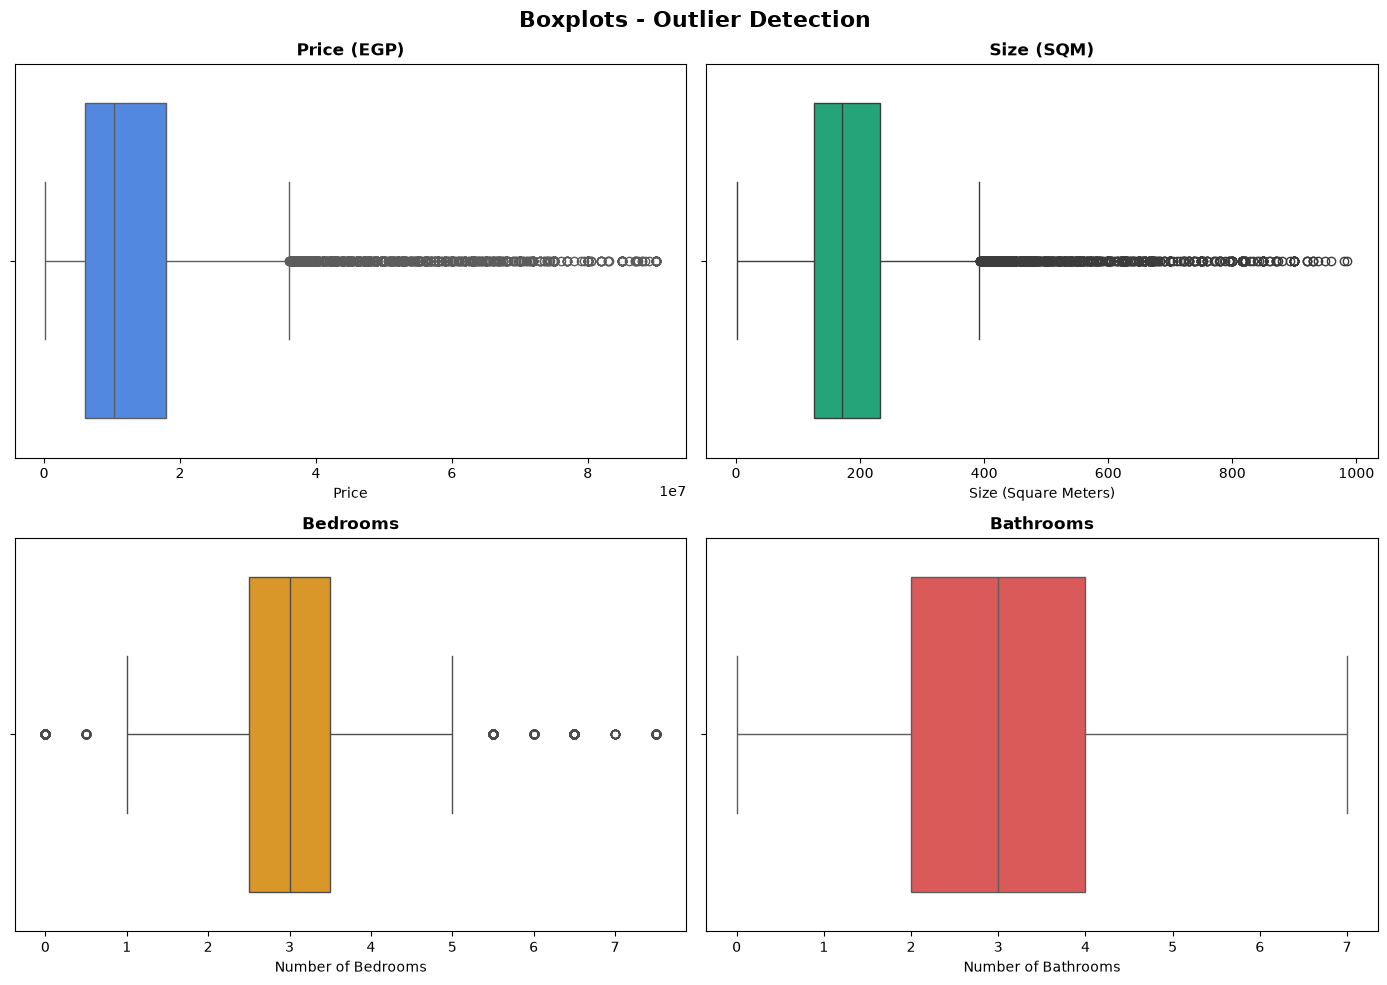

In [37]:
numeric_cols = ['price', 'size_sqm', 'bedrooms', 'bathrooms']


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Boxplots - Outlier Detection', fontsize=16, fontweight='bold')

# Price
sns.boxplot(x=df['price'], ax=axes[0,0], color='#3B82F6')
axes[0,0].set_title('Price (EGP)', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Price')

# Size
sns.boxplot(x=df['size_sqm'], ax=axes[0,1], color='#10B981')
axes[0,1].set_title('Size (SQM)', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Size (Square Meters)')

# Bedrooms
sns.boxplot(x=df['bedrooms'], ax=axes[1,0], color='#F59E0B')
axes[1,0].set_title('Bedrooms', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Number of Bedrooms')

# Bathrooms
sns.boxplot(x=df['bathrooms'], ax=axes[1,1], color='#EF4444')
axes[1,1].set_title('Bathrooms', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Number of Bathrooms')

plt.tight_layout()
plt.show()

now we will use IQR to remove outliers

In [38]:
def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        df_clean = df_clean[(df_clean[col] >= lower_bound) & 
                            (df_clean[col] <= upper_bound)]
    
    return df_clean

numeric_cols = ['price', 'size_sqm', 'bedrooms']
df= remove_outliers_iqr(df, numeric_cols)

In [39]:
df.info()

<class 'pandas.DataFrame'>
Index: 16244 entries, 0 to 19923
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   price           16244 non-null  float64
 1   location        16244 non-null  str    
 2   type            16244 non-null  str    
 3   bedrooms        16244 non-null  float64
 4   bathrooms       16244 non-null  float64
 5   payment_method  16244 non-null  str    
 6   size_sqm        16244 non-null  float64
dtypes: float64(4), str(3)
memory usage: 1.8 MB


In [40]:
df.head()

,price,location,type,bedrooms,bathrooms,payment_method,size_sqm
0,8000000.0,"Al Gouna, Hurghada, Red Sea",Chalet,1.5,1.0,Cash,68.0
1,25000000.0,"New Zayed City, Sheikh Zayed City, Giza",Villa,4.0,4.0,Cash,220.0
2,15135000.0,"Azha North, Ras Al Hekma, North Coast",Chalet,2.0,2.0,Cash,118.0
3,12652000.0,"The 5th Settlement, New Cairo City, Cairo",Apartment,3.0,2.0,Installments,166.0
5,19760000.0,"Marina, Al Alamein, North Coast",Chalet,3.0,2.0,Installments,126.0


In [41]:
#df.to_csv('egypt_real_estate_cleaned2.csv', index=False)

now we will do two more Visualizations before splite the data 

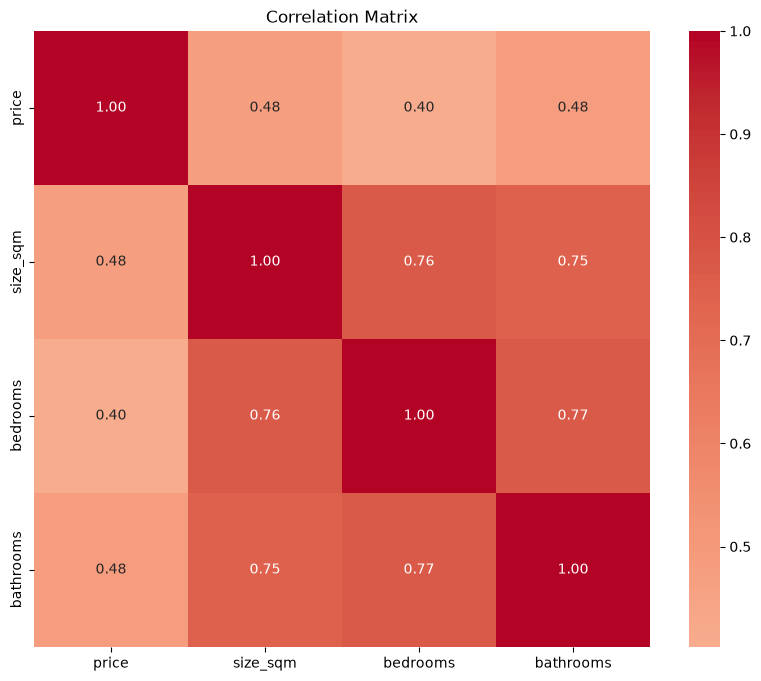

In [42]:
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df[['price', 'size_sqm', 'bedrooms', 'bathrooms']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
ax.set_title('Correlation Matrix')
plt.show()

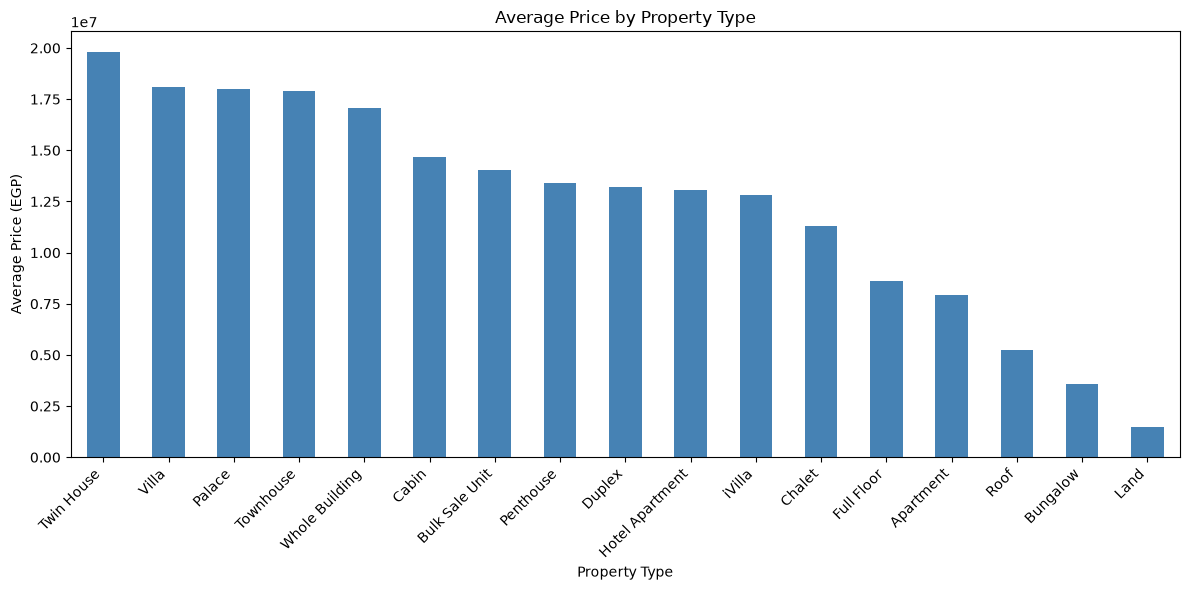

In [44]:
fig, ax = plt.subplots(figsize=(12, 6))
df.groupby('type')['price'].mean().sort_values(ascending=False).plot(kind='bar', ax=ax, color='steelblue')
ax.set_xlabel('Property Type')
ax.set_ylabel('Average Price (EGP)')
ax.set_title('Average Price by Property Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

now we will start Encoding

In [55]:
X = df.drop('price', axis=1)
y = df['price']

numeric_features = ['size_sqm', 'bedrooms', 'bathrooms']
categorical_features = ['type', 'location', 'payment_method']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

X_processed = preprocessor.fit_transform(X)

print(f"Original columns: {len(X.columns)}")
print(f"Encoded columns: {X_processed.shape[1]}")
print(f"New shape: {X_processed.shape}")

Original columns: 6
Encoded columns: 494
New shape: (16244, 494)


now we will split the data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

Train: 12995, Test: 3249


now we will start with our first model "Linear Regression"

In [62]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_pred)

print("\n" + "="*35)
print("LINEAR REGRESSION RESULTS")
print("="*35)
print(f"MAE:  {lr_mae:,.2f}")
print(f"MSE:  {lr_mse:,.2f}")
print(f"RMSE: {lr_rmse:,.2f}")
print(f"R²:   {lr_r2:.4f}")


LINEAR REGRESSION RESULTS
MAE:  3,497,599.16
MSE:  23,420,397,424,777.18
RMSE: 4,839,462.51
R²:   0.5791


let's see the coefficients

In [93]:
for i, feat in enumerate(['size_sqm', 'bedrooms', 'bathrooms']):
    print(f"{feat}: {lr_model.coef_[i]:,.0f}")

print(f"Intercept: {lr_model.intercept_:,.0f}")

size_sqm: 2,622,476
bedrooms: -214,852
bathrooms: 668,576
Intercept: 10,122,777


now with the secound one "KNN REGRESSOR" and we will use model selection to choose the best k and weights

In [64]:
param_grid = {'n_neighbors': list(range(1, 31)),'weights': ['uniform', 'distance']}
knn_base = KNeighborsRegressor()
knn_grid = GridSearchCV(knn_base, param_grid, cv=5, scoring='r2', n_jobs=-1)
knn_grid.fit(X_train, y_train)
best_knn = knn_grid.best_estimator_
knn_pred = best_knn.predict(X_test)

knn_mae = mean_absolute_error(y_test, knn_pred)
knn_mse = mean_squared_error(y_test, knn_pred)
knn_rmse = np.sqrt(knn_mse)
knn_r2 = r2_score(y_test, knn_pred)

print("\n" + "="*35)
print("KNN REGRESSOR RESULTS")
print("="*35)
print(f"Best params: {knn_grid.best_params_}")
print(f"MAE:  {knn_mae:,.2f}")
print(f"MSE:  {knn_mse:,.2f}")
print(f"RMSE: {knn_rmse:,.2f}")
print(f"R²:   {knn_r2:.4f}")


KNN REGRESSOR RESULTS
Best params: {'n_neighbors': 17, 'weights': 'distance'}
MAE:  3,312,085.29
MSE:  23,844,507,445,566.92
RMSE: 4,883,083.80
R²:   0.5715


Now we will comparison models

In [69]:
print("\n" + "="*55)
print("MODEL COMPARISON")
print("="*55)
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'KNN'],
    'MAE': [lr_mae, knn_mae],
    'RMSE': [lr_rmse, knn_rmse],
    'R²': [lr_r2, knn_r2]
})
print(comparison.to_string(index=False))

print("\nBest Model: Linear Regression")


MODEL COMPARISON
            Model          MAE         RMSE       R²
Linear Regression 3.497599e+06 4.839463e+06 0.579122
              KNN 3.312085e+06 4.883084e+06 0.571501

Best Model: Linear Regression


the Linear Regression is better but still not good enogh so we will try another model

In [70]:
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print(f"MAE:  {mean_absolute_error(y_test, rf_pred):,.0f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, rf_pred)):,.0f}")
print(f"R²:   {r2_score(y_test, rf_pred):.4f}")

MAE:  3,218,564
RMSE: 4,715,604
R²:   0.6004


In [71]:
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_grid = GridSearchCV(rf_base, rf_params, cv=5, scoring='r2', n_jobs=-1, verbose=1)
rf_grid.fit(X_train, y_train)

rf_best = rf_grid.best_estimator_
rf_pred = rf_best.predict(X_test)

print(f"Best params: {rf_grid.best_params_}")
print(f"MAE:  {mean_absolute_error(y_test, rf_pred):,.0f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, rf_pred)):,.0f}")
print(f"R²:   {r2_score(y_test, rf_pred):.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 300}
MAE:  3,220,255
RMSE: 4,624,318
R²:   0.6157


Random Forest is better but we will try one more model

In [73]:
xgb_params = {
    'n_estimators': [200, 300, 400],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2]
}

xgb_base = XGBRegressor(random_state=42, n_jobs=-1)
xgb_grid = GridSearchCV(xgb_base, xgb_params, cv=5, scoring='r2', n_jobs=-1, verbose=1)
xgb_grid.fit(X_train, y_train)

xgb_best = xgb_grid.best_estimator_
xgb_pred = xgb_best.predict(X_test)

print(f"\nBest params: {xgb_grid.best_params_}")
print(f"MAE:  {mean_absolute_error(y_test, xgb_pred):,.0f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, xgb_pred)):,.0f}")
print(f"R²:   {r2_score(y_test, xgb_pred):.4f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits

Best params: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 400}
MAE:  3,236,124
RMSE: 4,577,291
R²:   0.6235


In [74]:
xgb_params = {
    'n_estimators': list(range(100, 501, 100)),
    'max_depth': list(range(3, 11)),
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2]
}

xgb_base = XGBRegressor(random_state=42, n_jobs=-1)
xgb_grid = GridSearchCV(xgb_base, xgb_params, cv=5, scoring='r2', n_jobs=-1, verbose=1)
xgb_grid.fit(X_train, y_train)

xgb_best = xgb_grid.best_estimator_
xgb_pred = xgb_best.predict(X_test)

print(f"\nBest params: {xgb_grid.best_params_}")
print(f"MAE:  {mean_absolute_error(y_test, xgb_pred):,.0f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, xgb_pred)):,.0f}")
print(f"R²:   {r2_score(y_test, xgb_pred):.4f}")

Fitting 5 folds for each of 200 candidates, totalling 1000 fits

Best params: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 400}
MAE:  3,180,655
RMSE: 4,531,340
R²:   0.6310


In [80]:
xgb_final_params = {
    'n_estimators': [350, 400, 450, 500, 550, 600],     
    'max_depth': [7, 8, 9, 10, 11, 12],               
    'learning_rate': [0.05, 0.08, 0.1, 0.12],           
    'subsample': [0.85, 0.95, 1.0],                    
    'colsample_bytree': [0.75, 0.85, 0.95]              
}

xgb_base = XGBRegressor(random_state=42, n_jobs=-1)
xgb_grid_final = GridSearchCV(xgb_base, xgb_final_params, cv=5, scoring='r2', n_jobs=-1, verbose=1)
xgb_grid_final.fit(X_train, y_train)

xgb_final_best = xgb_grid_final.best_estimator_
xgb_final_pred = xgb_final_best.predict(X_test)

print(f"\nBest params: {xgb_grid_final.best_params_}")
print(f"MAE:  {mean_absolute_error(y_test, xgb_final_pred):,.0f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, xgb_final_pred)):,.0f}")
print(f"R²:   {r2_score(y_test, xgb_final_pred):.4f}")

Fitting 5 folds for each of 1296 candidates, totalling 6480 fits

Best params: {'colsample_bytree': 0.75, 'learning_rate': 0.05, 'max_depth': 11, 'n_estimators': 500, 'subsample': 0.85}
MAE:  3,121,136
RMSE: 4,439,276
R²:   0.6459


now that is the best one of them all . let's see all of them in one table

In [82]:
data = {
    'Model': ['Linear Regression', 'KNN', 'Random Forest', 'XGBoost'],
    'MAE': [lr_mae, knn_mae, mean_absolute_error(y_test, rf_pred), mean_absolute_error(y_test, xgb_final_pred)],
    'RMSE': [lr_rmse, knn_rmse, np.sqrt(mean_squared_error(y_test, rf_pred)), np.sqrt(mean_squared_error(y_test, xgb_final_pred))],
    'R²': [lr_r2, knn_r2, r2_score(y_test, rf_pred), r2_score(y_test, xgb_final_pred)]
}

df = pd.DataFrame(data)
print(df.to_string(index=False))

            Model          MAE         RMSE       R²
Linear Regression 3.497599e+06 4.839463e+06 0.579122
              KNN 3.312085e+06 4.883084e+06 0.571501
    Random Forest 3.220255e+06 4.624318e+06 0.615712
          XGBoost 3.121136e+06 4.439276e+06 0.645851


In [ ]:
residuals = y_test - xgb_final_best.predict(X_test)
std_error = np.std(residuals)

sample_X = X_test[:5]
sample_y = y_test[:5]
predictions = xgb_final_best.predict(sample_X)

print("95% PREDICTION INTERVALS")
for i, (pred, actual) in enumerate(zip(predictions, sample_y)):
    margin = 1.96 * std_error
    lower = max(0, pred - margin)     # here we made it so it don't go blow 0 
    upper = pred + margin
    
    print(f"\nProperty {i+1}: Actual={actual:,.0f}, Predicted={pred:,.0f}")
    print(f"   95% CI: [{lower:,.0f}, {upper:,.0f}]")

95% PREDICTION INTERVALS

Property 1: Actual=9,300,000, Predicted=9,789,456
   95% CI: [1,088,812, 18,490,100]

Property 2: Actual=5,880,000, Predicted=4,834,937
   95% CI: [0, 13,535,581]

Property 3: Actual=9,750,000, Predicted=9,722,777
   95% CI: [1,022,133, 18,423,421]

Property 4: Actual=21,000,000, Predicted=15,379,061
   95% CI: [6,678,417, 24,079,705]

Property 5: Actual=33,999,999, Predicted=22,913,678
   95% CI: [14,213,034, 31,614,322]


Our model predicts prices with R² = 0.65, meaning 35% of price factors are unknown to us (like property condition, exact location, market timing). This creates uncertainty in predictions. We also make sure our intervals never go below 0 since prices can't be negative

In [ ]:
# BOOTSTRAP
n_bootstraps = 1000
bootstrapped_r2 = []
np.random.seed(42)

for _ in range(n_bootstraps):
    idx = np.random.choice(len(y_test), size=len(y_test), replace=True)
    boot_r2 = r2_score(y_test.iloc[idx], xgb_final_best.predict(X_test[idx]))
    bootstrapped_r2.append(boot_r2)

ci_lower = np.percentile(bootstrapped_r2, 2.5)
ci_upper = np.percentile(bootstrapped_r2, 97.5)

print(" BOOTSTRAP ANALYSIS")
print(f"R² Mean: {np.mean(bootstrapped_r2):.4f}")
print(f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")

# HYPOTHESIS TEST
t_stat, p_value = stats.ttest_1samp(bootstrapped_r2, 0.5)
print(f"\n HYPOTHESIS TEST")
print(f"H₀: R² = 0.5 (model is no better than random)")
print(f"H₁: R² > 0.5 (model has predictive power)")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print(" Reject H₀ - Model is significant!")
else:
    print(" Fail to reject H₀")

 BOOTSTRAP ANALYSIS
R² Mean: 0.6456
95% CI: [0.6186, 0.6716]

 HYPOTHESIS TEST
H₀: R² = 0.5 (model is no better than random)
H₁: R² > 0.5 (model has predictive power)
p-value: 0.000000
 Reject H₀ - Model is significant!


now we will save the models

In [96]:
joblib.dump(xgb_final_best, 'xgboost_model.pkl')
joblib.dump(rf_best, 'random_forest_model.pkl')
joblib.dump(lr_model, 'linear_regression_model.pkl')
joblib.dump(best_knn, 'knn_model.pkl')
joblib.dump(preprocessor, 'preprocessor.pkl')

['preprocessor.pkl']